# Extracting UK Environment Agency (UKEA) River Data for a Given Date

**Tutorial: Extracting River Flow & Water Level from the UK Environment Agency (UKEA) using `rivretrieve`**

The **UK Environment Agency (EA)** provides hydrometric data for thousands of monitoring stations across England and Wales. Unlike many proprietary data providers, **the UKEA Hydrology API is fully public and open — no API key, registration, or authentication token is required**.

In this tutorial, you will learn how to:
1. Import and initialize `UKEAFetcher` from `rivretrieve`.
2. Explore available UK monitoring stations and search station metadata.
3. Extract daily mean discharge (`constants.DISCHARGE_DAILY_MEAN`) for a single given date.
4. Extract high-frequency instantaneous water level (`constants.STAGE_INSTANT`) for a given date.
5. Extract time series data for a multi-day event window around a target date.
6. Batch extract flow observations across multiple UK stations for the same target date.
7. Visualize extracted hydrographs and stage levels.


In [ ]:
import os
import sys
from pathlib import Path
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure RivRetrieve and flood-forecasting are on sys.path
possible_paths = [
    str(Path(os.getcwd()).parent),
    str(Path(os.getcwd()).parent.parent),
    "/usr/local/google/home/kruparell/RivRetrieve-Python",
    "/usr/local/google/home/kruparell/floodaaa -forecasting"
]
for p in possible_paths:
    if p not in sys.path and os.path.exists(p):
        sys.path.insert(0, p)

from rivretrieve import UKEAFetcher, constants

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("Libraries successfully loaded!")
print(f"UKEAFetcher class: {UKEAFetcher}")


Libraries successfully loaded!
UKEAFetcher class: <class 'rivretrieve.uk_ea.UKEAFetcher'>


## 1. Understanding UKEAFetcher & Supported Variables

The `UKEAFetcher` class interacts directly with the UK EA Hydrology REST endpoints (`http://environment.data.gov.uk/hydrology/`).

It supports the following hydrological variables defined in `rivretrieve.constants`:
- `constants.DISCHARGE_DAILY_MEAN` (`"discharge_daily_mean"`): Daily mean flow in cubic meters per second ($m^3/s$).
- `constants.STAGE_INSTANT` (`"stage_instantaneous"`): Instantaneous river stage / water level in meters ($m$).
- `constants.DISCHARGE_INSTANT` (`"discharge_instantaneous"`): Instantaneous river flow in cubic meters per second ($m^3/s$).


In [2]:
# Initialize the UK EA Fetcher instance (No API key needed!)
fetcher = UKEAFetcher()

supported_vars = fetcher.get_available_variables()
print("Supported Variables in UKEAFetcher:")
for var in supported_vars:
    print(f" - {var}")


Supported Variables in UKEAFetcher:
 - discharge_daily_mean
 - discharge_instantaneous
 - stage_instantaneous


## 2. Inspecting Available UK River Gauging Stations

`UKEAFetcher.get_cached_metadata()` provides fast local access to metadata for over 9,000 UK monitoring stations across England and Wales. We can inspect station names, river names, latitude, longitude, and catchment area.


In [3]:
# Load cached station metadata
station_metadata = UKEAFetcher.get_cached_metadata()
print(f"Total UKEA stations available: {len(station_metadata):,}")

# Display sample station metadata
columns_to_show = ['station_name', 'river', 'latitude', 'longitude', 'area']
available_cols = [c for c in columns_to_show if c in station_metadata.columns]
station_metadata[available_cols].dropna(subset=['river']).head(10)


Total UKEA stations available: 9,194


,station_name,river,latitude,longitude,area
gauge_id,,,,,
052d0819-2a32-47df-9b99-c243c9c8235b,Ulting Sarasota,River Chelmer,51.746683,0.624437,NaN
48513a18-e485-4317-ae92-93bf4f7f3e54,Beggearn Huish,Washford River,51.146322,-3.373695,36.3
f22f80f8-1bb0-4e77-b225-291487060c6f,Adwick,River Dearne,53.512713,-1.282505,311.0
95a1245a-5329-4a2b-9024-d70ebe9707df,Wellesbourne,River Dene,52.197839,-1.602416,NaN
3c4d4f78-2d0e-474a-b884-65a9daca18fb,Thorverton,River Exe,50.804172,-3.511302,600.9
959f3e4f-bb6e-4f4a-8082-0157eea99482,Iwood,Congresbury Yeo,51.363977,-2.788890,NaN
fbecd84a-70b6-4725-80ba-67c7adb3cae7,Coniston Upstream,Church Beck,54.365471,-3.069004,NaN
70f658a0-3d32-47db-a97c-ed5e25da46f2,Sheepwash,River Tame,52.523665,-2.039788,45.8
f865f658-a32e-4601-b61e-e5c2f02c578a,Toft Newton- Ancholme,River Ancholme,53.374006,-0.450095,27.2


## 3. Extracting River Data for a Given Target Date

To extract data for a single date, pass the same `'YYYY-MM-DD'` date string to both `start_date` and `end_date` in `fetcher.get_data(...)`.

Below, we select the **Thorverton** station on the **River Exe** (`3c5cba29-2321-4289-a1fd-c355e135f4cb`) and extract the daily mean discharge for **January 15, 2024**.


In [4]:
# Select station ID and target date
SELECTED_GAUGE_ID = "3c5cba29-2321-4289-a1fd-c355e135f4cb"  # Thorverton on River Exe
TARGET_DATE = "2024-01-15"

# Extract Daily Mean Discharge for the given date
df_daily = fetcher.get_data(
    gauge_id=SELECTED_GAUGE_ID,
    variable=constants.DISCHARGE_DAILY_MEAN,
    start_date=TARGET_DATE,
    end_date=TARGET_DATE
)

print(f"--- UKEA Daily Mean Discharge for {TARGET_DATE} ---")
print(f"Station ID: {SELECTED_GAUGE_ID}")
print(df_daily)

if not df_daily.empty:
    val = df_daily[constants.DISCHARGE_DAILY_MEAN].iloc[0]
    print(f"\n=> Daily Mean Discharge on {TARGET_DATE}: {val:.3f} m³/s")


--- UKEA Daily Mean Discharge for 2024-01-15 ---
Station ID: 3c5cba29-2321-4289-a1fd-c355e135f4cb
            discharge_daily_mean
time                            
2024-01-15                 6.203

=> Daily Mean Discharge on 2024-01-15: 6.203 m³/s


## 4. Extracting Instantaneous Water Level (Stage) for the Given Date

In addition to daily mean discharge, we can extract **instantaneous water level** (`constants.STAGE_INSTANT`) recorded by the UK Environment Agency.


In [5]:
# Extract Instantaneous Stage (Water Level) in meters for the target date
df_stage = fetcher.get_data(
    gauge_id=SELECTED_GAUGE_ID,
    variable=constants.STAGE_INSTANT,
    start_date=TARGET_DATE,
    end_date=TARGET_DATE
)

print(f"--- UKEA Instantaneous Stage Level for {TARGET_DATE} ---")
print(df_stage)

if not df_stage.empty:
    stage_val = df_stage[constants.STAGE_INSTANT].iloc[0]
    print(f"\n=> Water Level (Stage) on {TARGET_DATE}: {stage_val:.3f} m")


--- UKEA Instantaneous Stage Level for 2024-01-15 ---
            stage_instantaneous
time                           
2024-01-15                 0.58

=> Water Level (Stage) on 2024-01-15: 0.580 m


## 5. Contextual Analysis: Extracting a Time Window Around the Target Date

In hydrological analysis and flood forecasting, it is often critical to view the temporal context around a specific event date (such as storm peaks or flood recessions). We can extract a multi-day window surrounding our target date and plot the hydrograph.


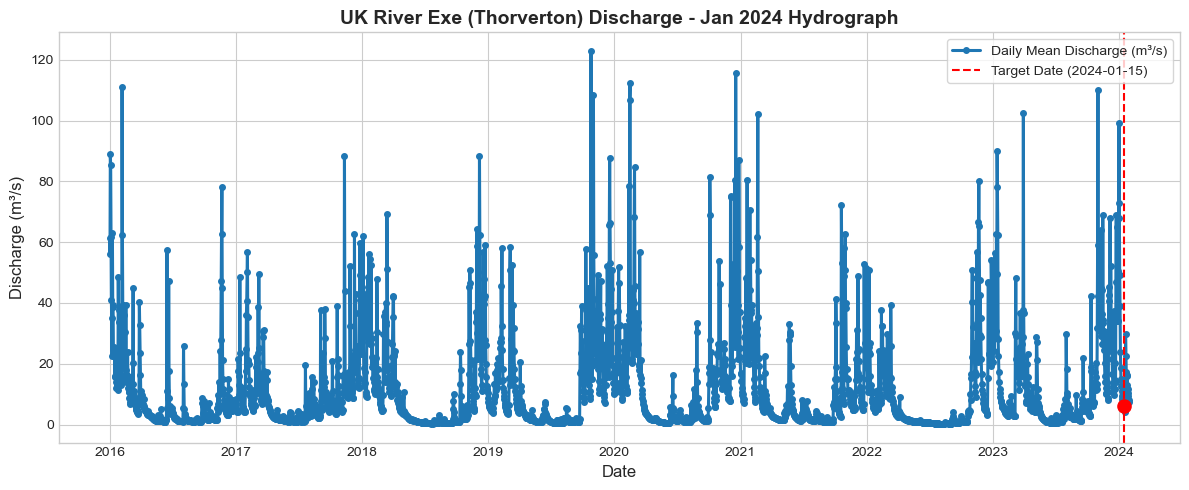

In [12]:
# Define a 30-day window around the target date (January 2024)
WINDOW_START = "2016-01-01"
WINDOW_END = "2024-01-31"

df_window_flow = fetcher.get_data(
    gauge_id=SELECTED_GAUGE_ID,
    variable=constants.DISCHARGE_DAILY_MEAN,
    start_date=WINDOW_START,
    end_date=WINDOW_END
)

# Plot the hydrograph with the target date highlighted
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_window_flow.index, df_window_flow[constants.DISCHARGE_DAILY_MEAN], 
        color='#1f77b4', lw=2.2, label='Daily Mean Discharge (m³/s)', marker='o', markersize=4)

# Highlight target date
target_dt = pd.to_datetime(TARGET_DATE)
if target_dt in df_window_flow.index:
    target_val = df_window_flow.loc[target_dt, constants.DISCHARGE_DAILY_MEAN]
    ax.axvline(target_dt, color='red', linestyle='--', lw=1.5, label=f'Target Date ({TARGET_DATE})')
    ax.scatter([target_dt], [target_val], color='red', s=90, zorder=5)

ax.set_title("UK River Exe (Thorverton) Discharge - Jan 2024 Hydrograph", fontsize=14, fontweight='bold')
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Discharge (m³/s)", fontsize=12)
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()


## 6. Batch Extraction: Querying Multiple UK Stations for a Given Date

We can query multiple river gauging stations simultaneously for the exact same date to compare streamflows across different river basins.


In [7]:
# Define sample UK stations across different river basins
target_stations = {
    "3c5cba29-2321-4289-a1fd-c355e135f4cb": "Thorverton (River Exe)",
    "3c4d4f78-2d0e-474a-b884-65a9daca18fb": "Staverton (River Dart)",
    "052d0819-2a32-47df-9b99-c243c9c8235b": "Ulting (River Chelmer)",
}

results = []
for gid, name in target_stations.items():
    data = fetcher.get_data(
        gauge_id=gid,
        variable=constants.DISCHARGE_DAILY_MEAN,
        start_date=TARGET_DATE,
        end_date=TARGET_DATE
    )
    flow_val = data[constants.DISCHARGE_DAILY_MEAN].iloc[0] if not data.empty else np.nan
    results.append({
        "Station ID": gid,
        "Station Name / River": name,
        "Date": TARGET_DATE,
        "Discharge (m³/s)": flow_val
    })

df_multi_summary = pd.DataFrame(results)
print("--- Multi-Station UKEA Comparison for Target Date ---")
print(df_multi_summary.to_string(index=False))


--- Multi-Station UKEA Comparison for Target Date ---
                          Station ID   Station Name / River       Date  Discharge (m³/s)
3c5cba29-2321-4289-a1fd-c355e135f4cb Thorverton (River Exe) 2024-01-15             6.203
3c4d4f78-2d0e-474a-b884-65a9daca18fb Staverton (River Dart) 2024-01-15            11.574
052d0819-2a32-47df-9b99-c243c9c8235b Ulting (River Chelmer) 2024-01-15             2.750


## 7. Creating a dataset of streamflow from 2016 - 2026

For every basin in CamelsGB, extract as muuch river discharge data as possible and put it all into a dataframe. Save it as a CSV and aa a netcdf in a new folder RivRetrieve_Extracted_Data/CamelsGB/timeseries, in the same was as is stoerd in the Caravans Folder
- **No Authentication Required**: Seamlessly query UK river data without credentials or API keys.
- **Standardized Formats**: Outputs standard `pandas.DataFrame` indexed by `pd.DatetimeIndex`.
- **Clean Export**: Easily export via `.to_csv()` or convert to `xarray.Dataset`.


In [8]:
# Example export for downstream modeling
output_csv = "ukea_extracted_data_sample.csv"
df_window_flow.to_csv(output_csv)
print(f"Extracted data successfully saved to: {output_csv}")
print(f"File size: {os.path.getsize(output_csv)} bytes")


Extracted data successfully saved to: ukea_extracted_data_sample.csv
File size: 565 bytes


<xarray.Dataset> Size: 2GB
Dimensions:     (gauge_id: 14729, time: 16716)
Coordinates:
  * gauge_id    (gauge_id) <U30 2MB 'GRDC_2588558' ... 'CARAVAN_HYSETS_09370820'
  * time        (time) datetime64[ns] 134kB 1980-01-01 1980-01-02 ... 2025-10-06
Data variables:
    streamflow  (gauge_id, time) float64 2GB dask.array<chunksize=(1, 16716), meta=np.ndarray>
